In [1]:
%load_ext autoreload
import sys
from pathlib import Path
import networkx as nx
import numpy as np
import seaborn as sns
from scipy.linalg import eigh
import matplotlib.pyplot as plt
import scipy.linalg as sla
import pandas as pd
import copy

In [2]:
project_root = Path().resolve()
sys.path.insert(0, str(project_root))
lib_path = project_root / "lib"
sys.path.insert(0, str(lib_path))        
sys.path.insert(0, str(project_root))   

In [3]:
%autoreload 2    
from lib.graph_factory import GraphFactory, add_graph_plot, calc_graph_metrics
from lib.utils import rng, seed
from lib.config import BASE_CONF, GLOBAL_SEED, NUM_NODES
from lib.metrics import effective_mixing, MetricsCalculator
from lib.utils import fetch_dataset, dirichlet_partition

In [4]:
def calc_constants(W, H, B, gamma_vec, pi_t, beta_C=0.1):
    Wb, pi, lam = effective_mixing(W, H, gamma_vec, pi_t)
    dp = dirichlet_partition(global_dataset['y_train'], NUM_NODES, config['data_heterogeneity'], rng('dir', 'data', 'graphs'))
    dB_max = max(W[i, B].sum() for i in H) if len(B) else 0.0

    alphas = 0.5
    mu = 1
    r_ub = np.clip((((alphas * mu) / (4*dB_max))-beta_C)/(1-beta_C), 0, 1)
    
    return dict(dB_max=dB_max, r_ub=r_ub)

In [5]:
def get_graph_args(num_byz_nodes):
    graph_args = {
        'ba_m': 5,
        'ws_k': 6,
        'ws_p': 0.1,
        'rand_reg_deg':10,
        'geom_radius':0.4,
        'er_p':min(1.0, 3.0 * np.log(NUM_NODES) / NUM_NODES),
    }
    if(num_byz_nodes == 5):
        r_ub = {
            'erdos-renyi': 0.1232,
            'random-regular': 0.0108,
            'watts-strogatz': 0.077,
            'geometric': 0.0789,
            'barabasi-albert': 0.0535
        }
        return graph_args, r_ub
        
    elif(num_byz_nodes <= 9 and num_byz_nodes > 5):
        r_ub = {
            'erdos-renyi': 0.1232,
            'random-regular': 0.0108,
            'watts-strogatz': 0.077,
            'geometric': 0.0789,
            'barabasi-albert': 0.0535
        }
        return graph_args, r_ub
    else: raise ValueError(f'No graph parameters for b={num_byz_nodes}')

In [14]:
config = copy.deepcopy(BASE_CONF)
config['graph_weights'] = 'MH_gen'

b = 5
h = NUM_NODES-b
graphs = ['erdos-renyi', 'random-regular','watts-strogatz', 'geometric', 'barabasi-albert']
local_seed = 333
gamma = np.clip((0.03*np.linspace(-1,1,NUM_NODES)) + 0.2, 0, 0.95)
pi_t = (1 - gamma) * np.full(NUM_NODES, 1.0/NUM_NODES)

In [7]:
global_dataset = fetch_dataset('MNIST')
mc = MetricsCalculator(config, global_dataset, rng('mc','exp11'))
gf = GraphFactory(NUM_NODES, b)

In [8]:
fig, ax = plt.subplots(1,1, figsize=(6,4))
sns.barplot(x=np.arange(NUM_NODES), y=np.sort(pi_t)[::-1], ax=ax)
ax.axhline(1/NUM_NODES, ls="--", color="crimson")
ax.set_title("Stationary Weight Distribution")
plt.close()

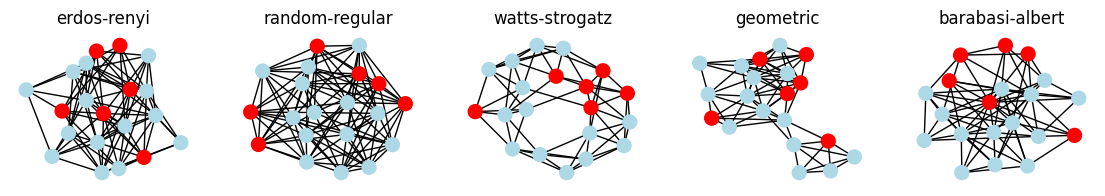

In [15]:
fig, ax = plt.subplots(1,5, figsize=(14,2))
df = pd.DataFrame()
for i, g in enumerate(graphs):
    metrics = {'graph_type':g}
    graph_args = get_graph_args(b)[0]
    graph_args['MH_target_pi'] = pi_t
    G,W,B,H = gf.create_graph(g, config['graph_weights'], local_seed, **graph_args)
    metrics.update(calc_constants(W, H, B, gamma, pi_t, beta_C=0.2))
    metrics.update(calc_graph_metrics(W,H,gamma,pi_t))
    df[g]= metrics
    add_graph_plot(G,B,ax[i])
    ax[i].set_title(g)
df = df.T
plt.show()

In [16]:
display(df)
display(df['r_ub'].apply(lambda arr: np.round(arr, 4)).to_dict())

,graph_type,dB_max,r_ub,spectral_gap,g
erdos-renyi,erdos-renyi,0.41864,0.123232,0.432949,0.321613
random-regular,random-regular,0.599215,0.010758,0.655082,0.412551
watts-strogatz,watts-strogatz,0.477853,0.076984,0.214538,0.02572
geometric,geometric,0.475098,0.07888,0.063055,0.000167
barabasi-albert,barabasi-albert,0.514743,0.053549,0.299704,0.271631


{'erdos-renyi': 0.1232,
 'random-regular': 0.0108,
 'watts-strogatz': 0.077,
 'geometric': 0.0789,
 'barabasi-albert': 0.0535}